In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
img1 = cv2.imread("ref.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("test.png", cv2.IMREAD_GRAYSCALE)

In [3]:
sift = cv2.SIFT_create()

kp1_sift, des1_sift = sift.detectAndCompute(img1, None)
kp2_sift, des2_sift = sift.detectAndCompute(img2, None)

bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches_sift = bf_sift.match(des1_sift, des2_sift)
matches_sift = sorted(matches_sift, key=lambda x: x.distance)

sift_result = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift, matches_sift[:30], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

orb = cv2.ORB_create(nfeatures=1000)

In [4]:
kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(des1_orb, des2_orb)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)

orb_result = cv2.drawMatches(img1, kp1_orb, img2, kp2_orb, matches_orb[:30], None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

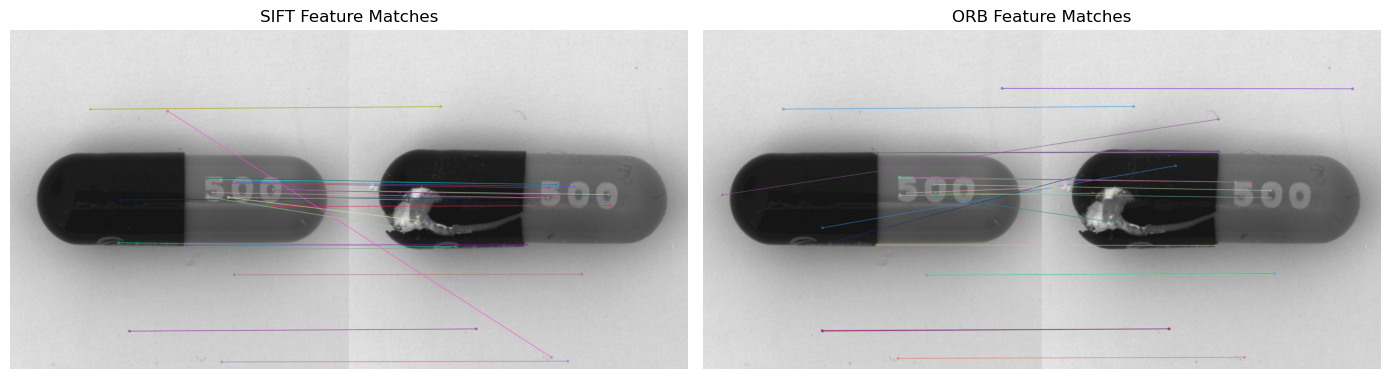

In [5]:
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.title("SIFT Feature Matches")
plt.imshow(sift_result)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("ORB Feature Matches")
plt.imshow(orb_result)
plt.axis("off")

plt.tight_layout()
plt.show()
